# Transistor sizing using $g_m/I_D$ method
Lookup Tables (LUTs) can be generating by running the following commands from the repository root
```bash
cd lib/gmid/src
PYTHONPATH=. python ../../ihp_analog_academy/modules/module_0_foundations/sg13_nmos_lv.py 
PYTHONPATH=. python ../../ihp_analog_academy/modules/module_0_foundations/sg13_pmos_lv.py 
cp sg13_nmos_lv_LUT.npz resources
cp sg13_pmos_lv_LUT.npz resources
```
This will create the files `sg13_nmos_lv_LUT.npz` and `sg13_pmos_lv_LUT.npz` under `lib/gmid/src` and copy them under the `resources` directory of the repository for easier access from this notebook.

This notebook aims to size three transistors for a cascode CG stage
<p align="center">
<img src="imag/Cascoded_CG.png">
</p>

# Lookup Table setup
This section assumes the lookup tables have been generated and placed in the corresponding `resources` folder in this repo.

In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

npz = np.load("../resources/sg13_nmos_lv_LUT.npz", allow_pickle=True)
lut = npz['lookup_table'].item()
nmos = lut['sg13_lv_nmos ']

nmos

{'id': array([[[[-0.00000000e+00,  1.58719343e-10,  2.02381001e-10, ...,
            5.44802981e-10,  5.86342752e-10,  6.28152197e-10],
          [-1.04042615e-14,  2.41558773e-09,  3.12278514e-09, ...,
            8.79062423e-09,  9.45588852e-09,  1.01124131e-08],
          [-2.81659292e-14,  3.78273803e-08,  4.95375367e-08, ...,
            1.46119149e-07,  1.57506889e-07,  1.68739419e-07],
          ...,
          [-5.80864072e-11,  1.10080873e-03,  1.80174818e-03, ...,
            2.87024304e-03,  2.91114161e-03,  2.94880429e-03],
          [-1.04861016e-10,  1.32343767e-03,  2.23591086e-03, ...,
            3.75588657e-03,  3.80614423e-03,  3.85164609e-03],
          [-1.82697441e-10,  1.52415980e-03,  2.63955817e-03, ...,
            4.67595737e-03,  4.73714573e-03,  4.79152659e-03]],
 
         [[ 1.31086131e-15,  1.04393362e-10,  1.35060810e-10, ...,
            3.86619570e-10,  4.17997220e-10,  4.49852905e-10],
          [-9.08722865e-15,  1.63604241e-09,  2.14408513e-09, ...,

In [154]:
## Turn the lookup table into a pandas dataframe
vgs = nmos['vgs']
vds = nmos['vds']
vbs = nmos['vbs']
L   = nmos['length']

ID  = nmos['id']
GM  = nmos['gm']
GDS = nmos['gds']
VTH = nmos['vth']

CGG = nmos['cgg']
CGS = nmos['cgs']
CBG = nmos['cbg']
CBS = nmos['cbs']
CGD = nmos['cgd']
CDD = nmos['cdd']

# Meshgrid with correct order
L_grid, VBS, VGS, VDS = np.meshgrid(L, vbs, vgs, vds, indexing='ij')

df = pd.DataFrame({
    "L": L_grid.ravel(),
    "VGS": VGS.ravel(),
    "VDS": VDS.ravel(),
    "VBS": VBS.ravel(),
    "ID": ID.ravel(),
    "GM": GM.ravel(),
    "GDS": GDS.ravel(),
    "VTH": VTH.ravel(),
    "CGG": CGG.ravel(),
    "CGS": CGS.ravel(),
    "CBG": CBG.ravel(),
    "CGD": CGD.ravel(),
    "CBS": CBS.ravel(),
})

df["GM_ID"] = df["GM"] / df["ID"]
df["ID_W"] = df["ID"] / nmos['device_parameters']['w']
df["GM_GDS"] = df["GM"] / df["GDS"]

df

,L,VGS,VDS,VBS,ID,GM,GDS,VTH,CGG,CGS,CBG,CGD,CBS,GM_ID,ID_W,GM_GDS
0,1.300000e-07,0.0,0.0,0.0,-0.000000e+00,-7.546090e-14,4.926868e-09,0.419227,8.540185e-16,3.367221e-19,8.539692e-16,3.367221e-19,-3.080416e-19,inf,-0.000000,-0.000015
1,1.300000e-07,0.0,0.1,0.0,1.587193e-10,4.293970e-09,4.972882e-10,0.419093,8.539302e-16,2.465718e-18,8.539034e-16,-1.918278e-18,-2.435713e-18,27.053852,0.000016,8.634771
2,1.300000e-07,0.0,0.2,0.0,2.023810e-10,5.503036e-09,4.252967e-10,0.418827,8.537791e-16,2.855851e-18,8.537536e-16,-2.466144e-18,-2.826313e-18,27.191467,0.000020,12.939288
3,1.300000e-07,0.0,0.3,0.0,2.449108e-10,6.706279e-09,4.365389e-10,0.418527,8.536089e-16,2.839508e-18,8.535836e-16,-2.623741e-18,-2.810144e-18,27.382542,0.000024,15.362385
4,1.300000e-07,0.0,0.4,0.0,2.891838e-10,7.930329e-09,4.387335e-10,0.418215,8.534322e-16,2.721932e-18,8.534069e-16,-2.685733e-18,-2.692621e-18,27.423145,0.000029,18.075504
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166967,9.880000e-06,1.2,0.8,-1.2,1.419171e-04,2.736646e-04,1.922471e-05,0.271924,9.055335e-13,8.424002e-13,3.706759e-14,3.774614e-14,4.980816e-14,1.928341,14.191710,14.235046
166968,9.880000e-06,1.2,0.9,-1.2,1.432653e-04,2.836106e-04,9.668788e-06,0.271924,8.813394e-13,8.440118e-13,3.787346e-14,1.039693e-14,4.981284e-14,1.979618,14.326531,29.332590
166969,9.880000e-06,1.2,1.0,-1.2,1.440590e-04,2.871711e-04,6.706723e-06,0.271924,8.747130e-13,8.435807e-13,3.807978e-14,3.779622e-15,4.978312e-14,1.993427,14.405897,42.818398
166970,9.880000e-06,1.2,1.1,-1.2,1.447297e-04,2.888738e-04,5.471123e-06,0.271924,8.726927e-13,8.431986e-13,3.814871e-14,2.013677e-15,4.976293e-14,1.995955,14.472965,52.799728


In [155]:
## Generate extra rows for plotting
df["GM_ID"] = df["GM"] / df["ID"]
df["ID_W"] = df["ID"] / nmos['device_parameters']['w']
df["GM_GDS"] = df["GM"] / df["GDS"]
df["FT"] = df["GM"] / (2 * np.pi * df["CGG"])

## Sizing $M_1$
In order to correctly size $M_1$ we must first select a bias current $I_{D0} that will yield around $80$ to $90\%$ of the saturated value of $g_m$. To better visualize the relationship between $g_m$ and $I_D$ we can plot the curve for the minimum channel length that the technology allows ($0.13\,\mu\mathrm{m}$ for SG13G2):

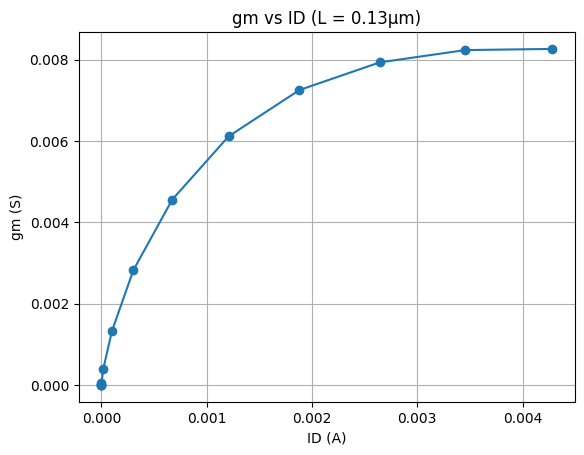

In [156]:
L_target = 0.13e-6    # Minimum possible channel length
VDS_target = vds[6]   # e.g. ~0.6 V
VBS_target = 0        # Body diode shorted to source

subset = df[
    (np.isclose(df["L"], L_target)) &
    (np.isclose(df["VDS"], VDS_target)) &
    (np.isclose(df["VBS"], VBS_target))
].copy()

# Sort by current
subset = subset.sort_values("ID")

plt.figure()

plt.plot(subset["ID"], subset["GM"], marker='o')

plt.xlabel("ID (A)")
plt.ylabel("gm (S)")
plt.title("gm vs ID (L = 0.13µm)")
plt.grid()

plt.show()

From this plot is easy to see that $g_m$ saturates around $8.2\,\mathrm{mS}$, so we can obtain the corresponding $I_{D0}$ value directly:

Max gm: 0.008262231945991516
gm_0: 0.006609785836189985
Corresponding ID_0: 0.0015020827357172034


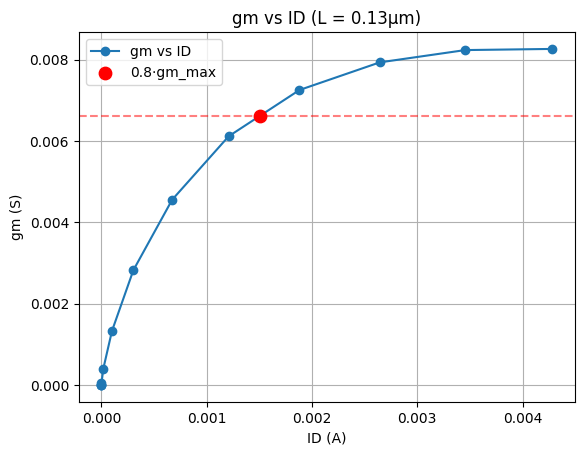

In [157]:
gm_max = subset["GM"].max()
gm_0 = 0.8 * gm_max

# Ensure sorted
sub = subset.sort_values("GM")

gm_vals = sub["GM"].values
id_vals = sub["ID"].values

ID_0 = np.interp(gm_0, gm_vals, id_vals)

print(f"Max gm: {gm_max}")
print(f"gm_0: {gm_0}")
print(f"Corresponding ID_0: {ID_0}")

plt.figure()

plt.plot(subset["ID"], subset["GM"], marker='o', label="gm vs ID")

# Highlight target point
plt.scatter(ID_0, gm_0, color='r', s=80, zorder=3, label="0.8·gm_max")
plt.axhline(gm_0, color='r', linestyle='--', alpha=0.5)

plt.xlabel("ID (A)")
plt.ylabel("gm (S)")
plt.title("gm vs ID (L = 0.13µm)")
plt.grid()
plt.legend()

plt.show()

With $g_{m0}$ and $I_{D0} selected, we can scale both of them to obtain the required input impedance of $1/g_{m1}=50\,\Omega$. Transistor width $W$ also scales by the same factor, so we can obtain all the dimensions for $M_1$:

In [158]:
alpha = 50**-1 / gm_0
gm_1 = alpha * gm_0 
ID_1 = alpha * ID_0
W_1  = alpha * nmos['device_parameters']['w']
V_DSsat1 = 2 / (gm_1 / ID_1)

print(f"alpha = {alpha}")
print(f"gm_1  = {gm_1}")
print(f"ID_1  = {ID_1}")
print(f"W_1   = {W_1}")
print(f"V_DSsat1 = {V_DSsat1}")

alpha = 3.0258166790008545
gm_1  = 0.019999999552965164
ID_1  = 0.0045450269949723465
W_1   = 3.0258166589192115e-05
V_DSsat1 = 0.45450270965616185


### Computing bias inductance $L_B$

The input of the circuit sees a pad capacitance to the substrate. Thus, $L_B$ must resonate with $C_\mathrm{pad} + C_{SB1} + C_{GS1}$ and its own capacitance at the frequency of interest. Accompanying $L_B$ is the parallel equivalent resistance $R_p = QL_B\omega$, which contributes noise and possibly attenuates
the input signal. Thus, $R_p$ must be at least ten times higher than $R_S = 50\,\Omega$ to prevent attenuation.

In [ ]:
# Find closest row to your operating point
row = subset.iloc[(subset["ID"] - ID_0).abs().argsort()[:1]]
CGS_ref = row["CGS"].values[0]
CBS_ref = row["CBS"].values[0]

CGS_1 = alpha * CGS_ref
CBS_1 = alpha * CBS_ref

print(f"CGS_1 = {CGS_1} F")
print(f"CBS_1 = {CBS_1} F")

CGS_1 = 1.3920778118019402e-14 F
CBS_1 = 1.151779625687755e-15 F


In [ ]:
C_pad = 500e-12  # 500 pF
C_tot = C_pad + CBS_1 + CGS_1
C_tot

np.float32(5.000151e-10)

## Sizing $M_B$
The bias of $M_1$ is set by $M_B$ and $I_\mathrm{REF}$. We need to keep $g_m/I_D$ in $M_B$ equal to $g_{m1}/I_{D1}$, but we can set $I_\mathrm{REF} = 0.2 I_{D1}$ to make the bias branch consume just one fifth of the current in the main branch. To ensure correct matching between $M_1$ and $M_B$ this means that $M_1$ must incorporate five unit transistors (five gate fingers) and $M_B$ just one unit transistor. This also means that $W_B = 0.2 W_1$.

In [161]:
I_REF = 0.2 * ID_1
W_B = 0.2 * W_1
print(f"I_REF = {I_REF}")
print(f"W_B   = {W_B}")

I_REF = 0.0009090053989944694
W_B   = 6.0516335906868335e-06


### Bypass capacitor $C_B$
$C_B$ must offer a very low impedance to ground compared with $R_S$. This capacitor bypasses noise from $M_B$ and $I_\mathrm{REF}$ to ground, preventing gate noise in $M_1$. Note that a low inductance ground is critical for correct operation of $C_B$, because the high frequency performance of this CG state degrades strongly if the impedance seen in series with the gate is comparable to $R_S$.

## Output tank
The load inductor $L_1$ must be selected so that it resonates with $C_{GD2} + C_{DB2}$, plus the input capacitance of the next stage and its own capacitance $C_1$. Since the voltage gain of the LNA is proportional to $R_1=QL_1\omega$, $R_1$ must be sufficiently large ($500$ to $1000\,\Omega$).